# SPIN — Example 2: viscous Burgers (long-horizon prediction)

This notebook reproduces the **Burgers** results from the paper (Fig. 4 and the
Burgers panel of Fig. 6).

A Gaussian pulse is advected and steepened by the viscous Burgers equation. We
build a **rank-4** hyper-reduced LSPG-QDEIM ROM from only the **first 4** full-order
snapshots, then predict **500 steps** — far beyond the training window, so the
comparison is deliberately *extrapolative*. We compare three ROMs that share the
exact same rank, sample count, and correction schedule:

- **static** — fixed basis, no adaptation (fails once the pulse leaves training);
- **baseline adaptive** — out-of-span corrections only (every $z_s$ steps);
- **SPIN** — the same corrections **plus** in-span learning between them.

The only algorithmic difference between baseline and SPIN is the in-span channel.


## 1 · Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))

import numpy as np
import matplotlib.pyplot as plt

import spin
from spin.core import compute_pod_basis, qdeim
from spin.problems.burgers import BurgersSolver, BurgersSpinROM
from spin.diagnostics import relative_l2_error
from spin.utils import use_paper_style, PALETTE, plot_profiles, plot_error_history
use_paper_style()

## 2 · Control variables

These defaults reproduce the paper. The two adaptive ROMs use forgetting factors
selected by the paper's ablation (best baseline `GAMMA_OUT_BASELINE=0.01`; best
SPIN `(GAMMA_IN, GAMMA_OUT)=(1.0, 0.25)`). Feel free to change the rank, the
correction interval `ZS`, or the forgetting factors and re-run.

In [2]:
# --- full-order model -------------------------------------------------
NX     = 256       # spatial grid points
L      = 1.0       # domain length
NU     = 1e-2      # viscosity
DT     = 1e-3      # time step
N_STEPS = 500      # prediction horizon

# --- reduced-order model ---------------------------------------------
R       = 4        # ROM rank
M       = 4        # QDEIM sample points
OFFLINE = 4        # number of training snapshots for the offline POD basis
ZS      = 10       # out-of-span correction interval

# --- forgetting factors (from the paper's ablation) ------------------
GAMMA_OUT_BASELINE = 0.01   # baseline adaptive: out-of-span forgetting
GAMMA_IN_SPIN      = 1.0    # SPIN: in-span forgetting
GAMMA_OUT_SPIN     = 0.25   # SPIN: out-of-span forgetting

# Newton tolerances of the reference run (these exact values reproduce the paper):
#   FOM_TOL : full-order Newton tolerance used to generate the snapshots
#   TOL     : ROM Newton tolerance (tight -> the inner solve runs to MAX_ITER)
FOM_TOL = 1e-8
TOL, MAX_ITER = 1e-20, 10

## 3 · Full-order model and offline basis

Solve the FOM once for the reference trajectory, then build the rank-`R` POD basis and QDEIM samples from only the first `OFFLINE` snapshots.

In [3]:
solver = BurgersSolver(Nx=NX, L=L, nu=NU, dt=DT)
snaps = solver.simulate(solver.initial_condition(), n_steps=N_STEPS, tol=FOM_TOL)   # (NX, N_STEPS+1)

Phi0, sigma0 = compute_pod_basis(snaps[:, :OFFLINE], R)
p_inds = qdeim(Phi0, M)
a0 = Phi0.T @ snaps[:, 0]
x = solver.x
print(f"FOM snapshots: {snaps.shape},  basis: {Phi0.shape},  samples: {p_inds}")

FOM snapshots: (256, 501),  basis: (256, 4),  samples: [125 139 108 156]


## 4 · Run the three ROMs

All three come from the *same* `BurgersSpinROM` driver — only the `mode` (and forgetting factors) differ.

In [4]:
def run(mode, gamma_in=1.0, gamma_out=0.25, record=False):
    rom = BurgersSpinROM(Phi0.copy(), sigma0.copy(), p_inds.copy(),
                         dt=DT, nu=NU, dx=solver.dx, zs=ZS,
                         mode=mode, gamma_in=gamma_in, gamma_out=gamma_out)
    return rom.simulate(a0.copy(), N_STEPS, tol=TOL, max_iter=MAX_ITER, record=record)

soln_static   = run("static")
soln_baseline = run("baseline", gamma_out=GAMMA_OUT_BASELINE)
soln_spin     = run("spin", gamma_in=GAMMA_IN_SPIN, gamma_out=GAMMA_OUT_SPIN)

err_static   = relative_l2_error(soln_static,   snaps)
err_baseline = relative_l2_error(soln_baseline, snaps)
err_spin     = relative_l2_error(soln_spin,     snaps)

print(f"mean relative L2 error over the horizon:")
print(f"  static            = {err_static.mean():.3e}")
print(f"  baseline adaptive = {err_baseline.mean():.3e}")
print(f"  SPIN              = {err_spin.mean():.3e}")

mean relative L2 error over the horizon:
  static            = 3.729e-01
  baseline adaptive = 5.480e-02
  SPIN              = 1.945e-02


The mean errors reproduce the paper: static $\approx$ 3.7e-1, baseline adaptive $\approx$ 5.5e-2, SPIN $\approx$ 1.9e-2. SPIN is consistently below the baseline **using the same correction budget**.

## 5 · Solution profiles (Fig. 4a)

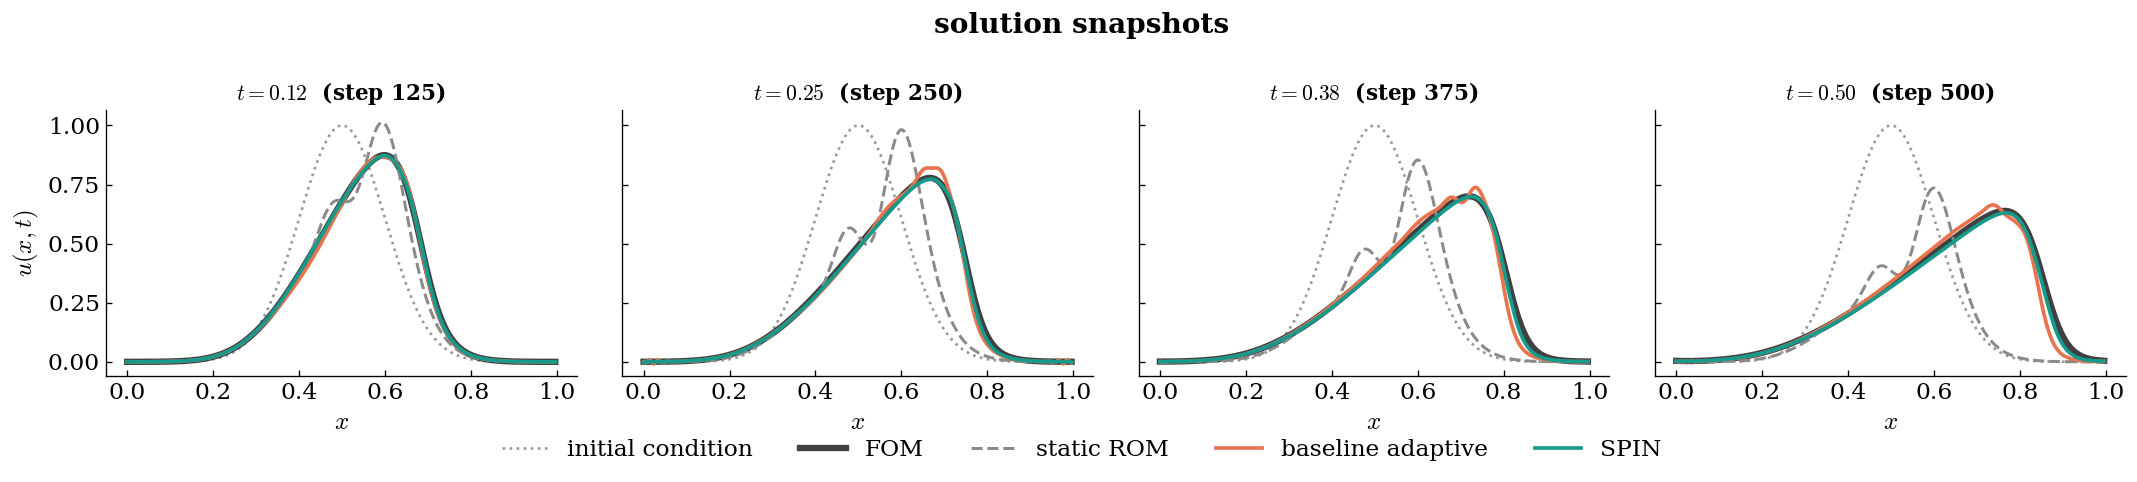

In [5]:
snap_steps = [N_STEPS//4, N_STEPS//2, 3*N_STEPS//4, N_STEPS]
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)
plot_profiles(axes, x, snaps[:, 0], snaps, soln_static, soln_baseline, soln_spin,
              snap_steps, DT)
axes[0].set_ylabel(r"$u(x,t)$")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("solution snapshots", fontweight="bold"); fig.tight_layout(); plt.show()

## 6 · Relative $L_2$ error history (Fig. 4b)

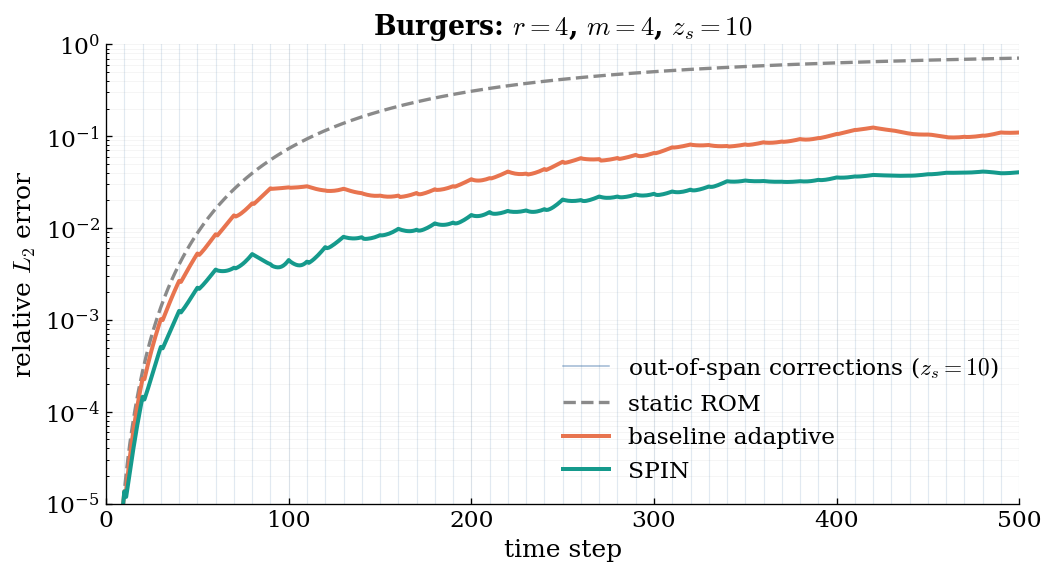

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_error_history(ax, err_static, err_baseline, err_spin, ZS,
                   title=rf"Burgers: $r={R}$, $m={M}$, $z_s={ZS}$")
ax.set_ylim(1e-5, 1e0); ax.legend(loc="lower right"); fig.tight_layout(); plt.show()

## 7 · Spectral diagnostics (Fig. 6a)

The same mechanism seen in the spiral leaves an algebraic fingerprint here. We
re-run baseline and SPIN with `record=True` to log the basis at every step, then
plot:

- the **singular-value histories** $\sigma_1,\dots,\sigma_4$ (baseline changes
  them only at corrections; SPIN reweights them every step);
- **basis reorientation** $\|I-\Phi_{k+1}^\top\Phi_k\|_F$ (nonzero between
  corrections only for SPIN — it rotates the basis in place);
- **genuine subspace motion** $\max_i\sin\theta_i$ (out-of-span events move the
  subspace; in-span events do not).

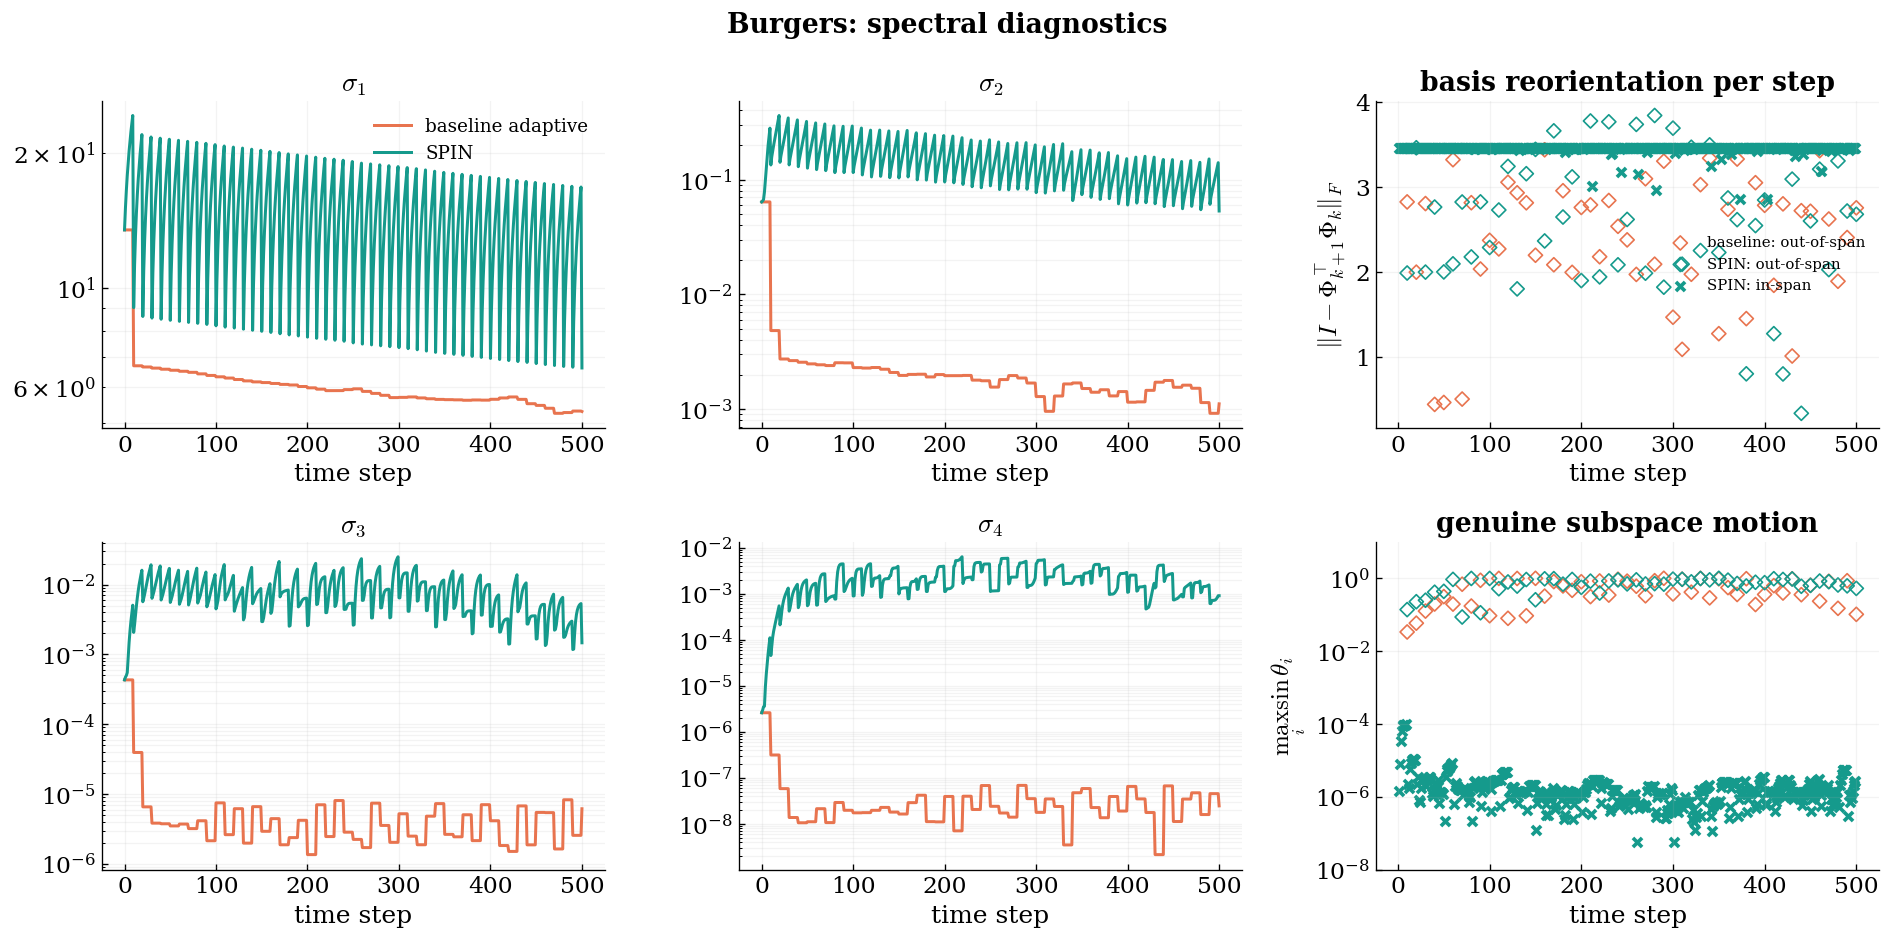

In [7]:
_, hist_baseline = run("baseline", gamma_out=GAMMA_OUT_BASELINE, record=True)
_, hist_spin     = run("spin", gamma_in=GAMMA_IN_SPIN, gamma_out=GAMMA_OUT_SPIN, record=True)

steps = hist_spin["step"]
Sb, Ss = hist_baseline["sigma"], hist_spin["sigma"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for j, ax in zip(range(R), [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]):
    ax.semilogy(steps, Sb[:, j], color=PALETTE["baseline"], lw=1.8, label="baseline adaptive")
    ax.semilogy(steps, Ss[:, j], color=PALETTE["spin"], lw=1.8, label="SPIN")
    ax.set_title(rf"$\sigma_{{{j+1}}}$"); ax.set_xlabel("time step"); ax.grid(alpha=0.15, which="both")
axes[0,0].legend(fontsize=11)

# basis reorientation per step (scatter, split by event type)
ax = axes[0, 2]
kb, ks = np.array(hist_baseline["kind"]), np.array(hist_spin["kind"])
rb, rs = hist_baseline["basis_reorientation"], hist_spin["basis_reorientation"]
ax.scatter(steps[kb=="out"], rb[kb=="out"], marker="D", facecolors="none",
           edgecolors=PALETTE["baseline"], s=36, label="baseline: out-of-span")
ax.scatter(steps[ks=="out"], rs[ks=="out"], marker="D", facecolors="none",
           edgecolors=PALETTE["spin"], s=36, label="SPIN: out-of-span")
ax.scatter(steps[ks=="in"], rs[ks=="in"], marker="x", c=PALETTE["spin"], s=30,
           label="SPIN: in-span")
ax.set_title("basis reorientation per step")
ax.set_xlabel("time step"); ax.set_ylabel(r"$\|I-\Phi_{k+1}^\top\Phi_k\|_F$")
ax.legend(fontsize=9, loc="center right"); ax.grid(alpha=0.15)

# genuine subspace motion (scatter)
ax = axes[1, 2]
sb = np.maximum(hist_baseline["subspace_change"], 1e-16)
ss = np.maximum(hist_spin["subspace_change"], 1e-16)
ax.scatter(steps[kb=="out"], sb[kb=="out"], marker="D", facecolors="none",
           edgecolors=PALETTE["baseline"], s=36)
ax.scatter(steps[ks=="out"], ss[ks=="out"], marker="D", facecolors="none",
           edgecolors=PALETTE["spin"], s=36)
ax.scatter(steps[ks=="in"], ss[ks=="in"], marker="x", c=PALETTE["spin"], s=30)
ax.set_yscale("log"); ax.set_ylim(1e-8, 1e1)
ax.set_title("genuine subspace motion")
ax.set_xlabel("time step"); ax.set_ylabel(r"$\max_i \sin\theta_i$"); ax.grid(alpha=0.15, which="both")

fig.suptitle("Burgers: spectral diagnostics", fontweight="bold", fontsize=16)
fig.tight_layout(); plt.show()

---
**Takeaway.** With the identical correction budget, SPIN keeps a lower error
across the whole horizon. The diagnostics confirm the *why*: in-span updates
continuously rotate and reweight the basis inside an essentially fixed subspace
(nonzero reorientation, ~zero subspace motion), preparing it to absorb each
out-of-span correction more effectively.